In [1]:
# !pip uninstall numpy scipy scikit-learn -y
# !pip install numpy scipy scikit-learn

In [2]:
# @title import dependencies
from __future__ import print_function, division
from typing import Mapping, Union, Optional

import numpy as np
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import plotly.graph_objects as go
import torchvision
from torchvision import datasets, models, transforms
import os
from tqdm.notebook import tqdm
from torch.utils.data import Dataset
import pandas as pd
import matplotlib.pyplot as plt 


In [3]:
# from sklearn.feature_extraction.text import TfidfVectorizer 
from nltk.tokenize import word_tokenize 
from nltk.stem.wordnet import WordNetLemmatizer 
from nltk.corpus import stopwords as sw 
import nltk
import re 
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [5]:
category_map = {
    0: "International News",
    1: "Business",
    2: "Technology",
    3: "Entertainment",
    4: "Sports",
    5: "General News",
    6: "Health"
}

In [6]:
#utility funcitons for preprocessing------------

def clean_text_without_url(text):
    if not isinstance(text, str):
        return ""

    # capturing alt captions from HTML before stripping tags
    captions = " ".join(re.findall(r'alt="([^"]*)"', text))
    captions = re.sub(r'[^a-zA-Z\s]', ' ', captions)

    # removing the URL messages 
    text_no_links = re.sub(r'https?://\S+', ' ', text)

    # remove HTML tags
    text_without_tags = re.sub(r'<[^>]+>', ' ', text_no_links)

    # keep information about money simbols
    text_without_tags = re.sub(
        r'[$€£¥]',
        ' MONEYAMOUNT ',
        text_without_tags
    )

    # this removes punctuation, numbers
    text_final = re.sub(r"[^a-zA-Z\s]", ' ', text_without_tags)

    combined = text_final  + " " + captions

    # 6. lower casse and extra whitespace removal
    return re.sub(r'\s+', ' ', combined).strip().lower()

clean_text = clean_text_without_url

def cleaner_applyer(df):
    df['title'] = df['title'].fillna('').apply(clean_text)
    df['article'] = df['article'].fillna('').apply(clean_text)
    df['source'] = df['source'].fillna('')
    df['combined_text'] = df['title'] + " " + df['article']
    df['combined_text2'] = df['title'] + " " + df['article']

from sklearn.base import BaseEstimator, TransformerMixin

class TextCleanerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self  # Non deve fare nulla in fase di fit
    
    def transform(self, X):
        # create a copy
        X = X.copy()
            
        cleaner_applyer(X)
        
        return X    

class LemmaTokenizerGood(object): 
    def __init__(self): 
        self.lemmatizer = WordNetLemmatizer() 
        self.stop_words = set(sw.words('english'))
    
    def __call__(self, document): 
        lemmas = [] 
        for t in word_tokenize(document): 
            t = t.lower().strip()
            
            # if t still contains some other character differente from letters, or it is the stopword set, or it is too shot, it is removed
            if t.isalpha() and t not in self.stop_words and len(t) > 2:
                # lemmatizing to extract its root form
                lemma = self.lemmatizer.lemmatize(t) 
                lemmas.append(lemma)
                
        return lemmas
    

lemmaTokenizer = LemmaTokenizerGood()   
text_transformer1 = TfidfVectorizer(
    max_features=250000, 
    tokenizer=lemmaTokenizer, 
    stop_words=None, 
    ngram_range=(1, 2), 
    sublinear_tf=True, 
    norm='l2', 
    use_idf = True,
    min_df=3, 
    max_df=0.12)

text_transformer_classic_char = TfidfVectorizer(analyzer='char',
    ngram_range=(3, 5),
    min_df=5,
    max_df=0.2,
    max_features=120_000,
    sublinear_tf=True,
    norm='l2',
    smooth_idf=True,
    use_idf=True)

source_transformer = OneHotEncoder(handle_unknown='ignore')


preprocessor_svc = ColumnTransformer(
    transformers=[
        ('text', text_transformer1, 'combined_text'),
        ('char', text_transformer_classic_char, 'combined_text2'), 
        ('source', source_transformer, ['source']),
        # ('pagerank', Pipeline([
        #     ('imputer', SimpleImputer(strategy='median')),
        #     ('scaler', MinMaxScaler())
        # ]), ['page_rank']),
        ('year', OneHotEncoder(handle_unknown='ignore'), ['year']),
        ('lenght', MinMaxScaler(), ['article_len'])
        
    ], remainder='drop'
)  

In [7]:
# You can skip this cell and read only the function docstring

import torch
import torch.nn.functional as F
from typing import Optional, Callable, Dict
from tqdm.notebook import tqdm, trange


def permute_pixels(images: torch.Tensor, perm: Optional[torch.Tensor]) -> torch.Tensor:
    """ Permutes the pixel in each image in the batch

    :param images: a batch of images with shape [batch, channels, w, h]
    :param perm: a permutation with shape [w * h]

    :returns: the batch of images permuted according to perm
    """
    if perm is None:
        return images

    batch_size = images.shape[0]
    n_channels = images.shape[1]
    w = images.shape[2]
    h = images.shape[3]
    images = images.view(batch_size, n_channels, -1)
    images = images[..., perm]
    images = images.view(batch_size, n_channels, w, h)
    return images


def make_averager() -> Callable[[Optional[float]], float]:
    """ Returns a function that maintains a running average

    :returns: running average function
    """
    count = 0
    total = 0

    def averager(new_value: Optional[float]) -> float:
        """ Running averager

        :param new_value: number to add to the running average,
                          if None returns the current average
        :returns: the current average
        """
        nonlocal count, total
        if new_value is None:
            return total / count if count else float("nan")
        count += 1
        total += new_value
        return total / count

    return averager

def test_model(
    test_dl: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    perm: Optional[torch.Tensor] = None,
    device: str = "cuda",
) -> Dict[str, Union[float, Callable[[Optional[float]], float]]]:
    
    model.eval()
    test_loss_averager = make_averager()
    correct = 0

    # CRITICAL FIX 1: Stop PyTorch from tracking gradients/graphs
    with torch.no_grad(): 
        for batch in test_dl:
            data = batch['x'].to(device)
            target = batch['y'].to(device)

            if perm is not None:
                data = permute_pixels(data, perm)

            output = model(data)

            # CRITICAL FIX 2: Use .item() to avoid keeping the tensor on GPU
            loss_val = F.cross_entropy(output, target).item()
            test_loss_averager(loss_val)

            # get the index of the max probability
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).cpu().sum().item()

    return {
        "accuracy": 100.0 * correct / len(test_dl.dataset),
        "loss_averager": test_loss_averager,
        "correct": correct,
    }





def get_model_optimizer(model: torch.nn.Module) -> torch.optim.Optimizer:
    """
    Encapsulate the creation of the model's optimizer, to ensure that we use the
    same optimizer everywhere

    :param model: the model that contains the parameters to optimize

    :returns: the model's optimizer
    """
    return optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    # return optim.SGD(model.parameters(), lr=0.01, momentum=0.1, weight_decay=1e-5)


In [8]:
def sparsity_index(model, threshold=1e-3):
    total = 0
    active = 0
    for param in model.parameters():
        total += param.numel()
        active += (param.abs() > threshold).sum().item()
    
    return active / total  # fraction of active params

In [9]:
def fit(
    epochs: int,
    train_dl: torch.utils.data.DataLoader,
    test_dl: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    opt: torch.optim.Optimizer,
    tag: str,
    loss_fn: callable = F.cross_entropy,
    perm: Optional[torch.Tensor] = None,
    device: str = "cuda",
    scheduler: Optional[object] = None,
) -> dict:
    """Train the model and computes metrics on the test_loader at each epoch

    :param epochs: number of epochs
    :param train_dl: the train dataloader
    :param test_dl: the test dataloader
    :param model: the model to train
    :param opt: the optimizer to use to train the model
    :param tag: description of the current model
    :param loss_fn: loss function to use (default: F.cross_entropy)
    :param perm: if not None, permute the pixel in each image according to perm

    :returns: dict with 'accuracy' (final test accuracy) and 'history' (per-epoch metrics)
    """
    history = {
        "train_loss": [],
        "test_loss": [],
        "train_accuracy": [],
        "test_accuracy": [],
        "lr": [],
    }

    for epoch in trange(epochs, desc="train epoch"):
        model.train()
        train_loss_averager = make_averager()
        train_correct = 0
        train_total = 0

        # TRAIN
        tqdm_iterator = tqdm(
            enumerate(train_dl),
            total=len(train_dl),
            desc=f"batch [loss: None]",
            leave=False,
        )
        for batch_idx, batch in tqdm_iterator:
            data = batch['x'].to(device)
            target = batch['y'].to(device)

            if perm is not None:
                data = permute_pixels(data, perm)

            output = model(data)
            loss = loss_fn(output, target)
            loss.backward()
            opt.step()
            opt.zero_grad()

            train_loss_averager(loss.item())

            # accumulate train accuracy
            pred = output.argmax(dim=1)
            train_correct += pred.eq(target).sum().item()
            train_total += target.size(0)

            tqdm_iterator.set_description(
                f"train batch [avg loss: {train_loss_averager(None):.3f}]"
            )
            tqdm_iterator.refresh()

        # TEST
        test_out = test_model(test_dl, model, perm, device)

        # SCHEDULER STEP
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_out['accuracy'])
            else:
                scheduler.step()

        current_lr = opt.param_groups[0]['lr']
        train_accuracy = 100.0 * train_correct / train_total

        # record history
        history["train_loss"].append(train_loss_averager(None))
        history["test_loss"].append(test_out['loss_averager'](None))
        history["train_accuracy"].append(train_accuracy)
        history["test_accuracy"].append(test_out['accuracy'])
        history["lr"].append(current_lr)

        print(
            f"Epoch: {epoch}\n"
            f"Train set: Average loss: {train_loss_averager(None):.4f}, "
            f"Accuracy: {train_correct}/{train_total} ({train_accuracy:.0f}%)\n"
            f"Test set:  Average loss: {test_out['loss_averager'](None):.4f}, "
            f"Accuracy: {test_out['correct']}/{len(test_dl.dataset)} "
            f"({test_out['accuracy']:.0f}%) | LR: {current_lr:.6f}\n"
        )
        # sparsity index
        pct_active = sparsity_index(model, threshold=1e-3)
        print(f"Active parameters: {pct_active:.2%}")
    return {"accuracy": test_out['accuracy'], "history": history}

In [10]:
from sklearn.model_selection import train_test_split

# %% 
# 1. Load and Split
df_full = pd.read_csv("development.csv")
df_full = df_full.drop_duplicates(subset=['article']).reset_index(drop=True)
df_full = df_full[df_full['article'].fillna('').str.len() >= 50].copy()

df_train, df_val = train_test_split(df_full, test_size=0.2, random_state=42, stratify=df_full['label'])

# 2. FEATURE ENGINEERING FUNCTION
def engineer_features(df):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['year'] = df['timestamp'].dt.year.fillna(0)
    df['article_len'] = df['article'].fillna('').str.len()
    return df

# Apply to both
df_train = engineer_features(df_train)
df_val = engineer_features(df_val)

# 3. Fit/Transform
cleaner = TextCleanerTransformer()

# TRAIN
X_train_clean = cleaner.fit_transform(df_train)
X_train_encoded = preprocessor_svc.fit_transform(X_train_clean)

# VALIDATION (Now it has the 'year' and 'article_len' columns!)
X_val_clean = cleaner.transform(df_val)
X_val_encoded = preprocessor_svc.transform(X_val_clean)

C:\Users\aless\AppData\Local\Temp\ipykernel_17108\129714502.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [11]:
class ArticleDataset(Dataset):
    def __init__(self, x_encoded, y_labels):
        """
        Args:
            x_encoded: The output from preprocessor_svc.transform() (Sparse or Dense)
            y_labels: The 'label' column as a numpy array/list
        """
        self.x = x_encoded
        self.y = y_labels
        self.n_points = x_encoded.shape[0]

    def __len__(self):
        return self.n_points

    def __getitem__(self, idx):
        x_data = self.x[idx]
        
        # Handle SciPy sparse matrix if necessary
        if hasattr(x_data, "toarray"):
            x_data = x_data.toarray().squeeze()

        return {
            'x': torch.tensor(x_data, dtype=torch.float32),
            'y': torch.tensor(self.y[idx], dtype=torch.long)
        }

In [12]:
# Create the instances
train_dataset = ArticleDataset(X_train_encoded, df_train['label'].values)
val_dataset = ArticleDataset(X_val_encoded, df_val['label'].values)

# Create DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [13]:
class FCNLayer(nn.Module):
    def __init__(
        self, input_size: int, n_hidden: int, output_size: int, n_layers: int = 2
    ) -> None:
        super().__init__()
        
        layers = [nn.Linear(input_size, n_hidden), nn.ReLU()]
        
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.ReLU()]
        
        layers.append(nn.Linear(n_hidden, output_size))
        
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.shape[0], -1)
        return self.network(x)

In [20]:
class FCNLayerDropout(nn.Module):
    def __init__(
        self, input_size: int, n_hidden: int, output_size: int, n_layers: int = 2
    ) -> None:
        super().__init__()
        
        layers = [nn.Linear(input_size, n_hidden), nn.ReLU()]
        
        for _ in range(n_layers - 1):
            layers += [nn.Dropout(p=0.5)]
            layers += [nn.Linear(n_hidden, n_hidden), nn.ReLU()]
            
        
        layers.append(nn.Linear(n_hidden, output_size))
        
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.shape[0], -1)
        return self.network(x)

In [21]:
# torch.cuda.memory_summary()

In [22]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Initialize Model
# We get the input size directly from the shape of our encoded training data
input_dim = X_train_encoded.shape[1]
num_classes = len(df_train['label'].unique())

model2 = FCNLayerDropout(
    input_size=input_dim,  
    n_hidden=64,
    n_layers=2, 
    output_size=num_classes
).to(device)

# 2. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-3, weight_decay = 1e-3)
# optimizer = optim.SGD(model2.parameters(), lr=0.1, momentum=0.9, weight_decay=1)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

def custom_loss(outputs, targets, model, lambda_reg=1e-4):
    # Cross-entropy loss
    ce_loss = F.cross_entropy(outputs, targets)
    
    # L2 regularization (sum of squared weights)
    l2_reg = sum(param.pow(2).sum() for param in model.parameters())
    
    return ce_loss + lambda_reg * l2_reg

# 3. Training Hyperparameters
epochs = 10

Using device: cpu


In [23]:
result = fit(epochs= epochs, train_dl= train_loader, test_dl= val_loader, model = model2, opt = optimizer, perm = None, device = device, tag = "fnn", scheduler=scheduler)

train epoch:   0%|          | 0/10 [00:00<?, ?it/s]

batch [loss: None]:   0%|          | 0/922 [00:00<?, ?it/s]

Epoch: 0
Train set: Average loss: 1.1101, Accuracy: 34668/58948 (59%)
Test set:  Average loss: 0.8384, Accuracy: 10185/14738 (69%) | LR: 0.001000

Active parameters: 53.62%


batch [loss: None]:   0%|          | 0/922 [00:00<?, ?it/s]

Epoch: 1
Train set: Average loss: 0.8545, Accuracy: 40385/58948 (69%)
Test set:  Average loss: 0.7826, Accuracy: 10335/14738 (70%) | LR: 0.001000

Active parameters: 56.50%


...

Epoch: 7
Train set: Average loss: 0.7313, Accuracy: 42383/58948 (72%)
Test set:  Average loss: 0.7344, Accuracy: 10499/14738 (71%) | LR: 0.001000

Active parameters: 57.51%


batch [loss: None]:   0%|          | 0/922 [00:00<?, ?it/s]

Epoch: 8
Train set: Average loss: 0.7224, Accuracy: 42584/58948 (72%)
Test set:  Average loss: 0.7331, Accuracy: 10507/14738 (71%) | LR: 0.001000

Active parameters: 57.07%


batch [loss: None]:   0%|          | 0/922 [00:00<?, ?it/s]

Epoch: 9
Train set: Average loss: 0.7228, Accuracy: 42585/58948 (72%)
Test set:  Average loss: 0.7292, Accuracy: 10495/14738 (71%) | LR: 0.000500

Active parameters: 56.97%


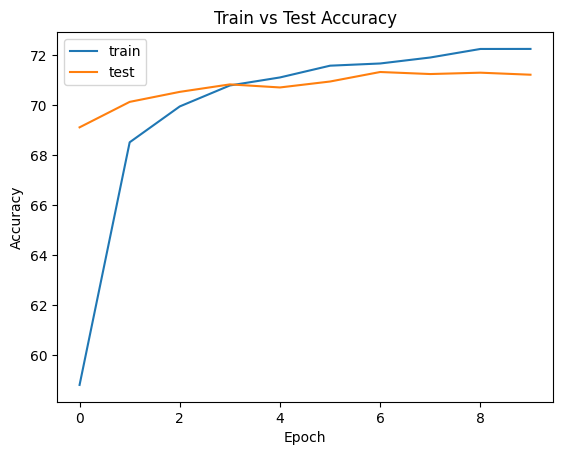

In [24]:
history = result["history"]
plt.plot(history["train_accuracy"], label="train")
plt.plot(history["test_accuracy"], label="test")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.show()

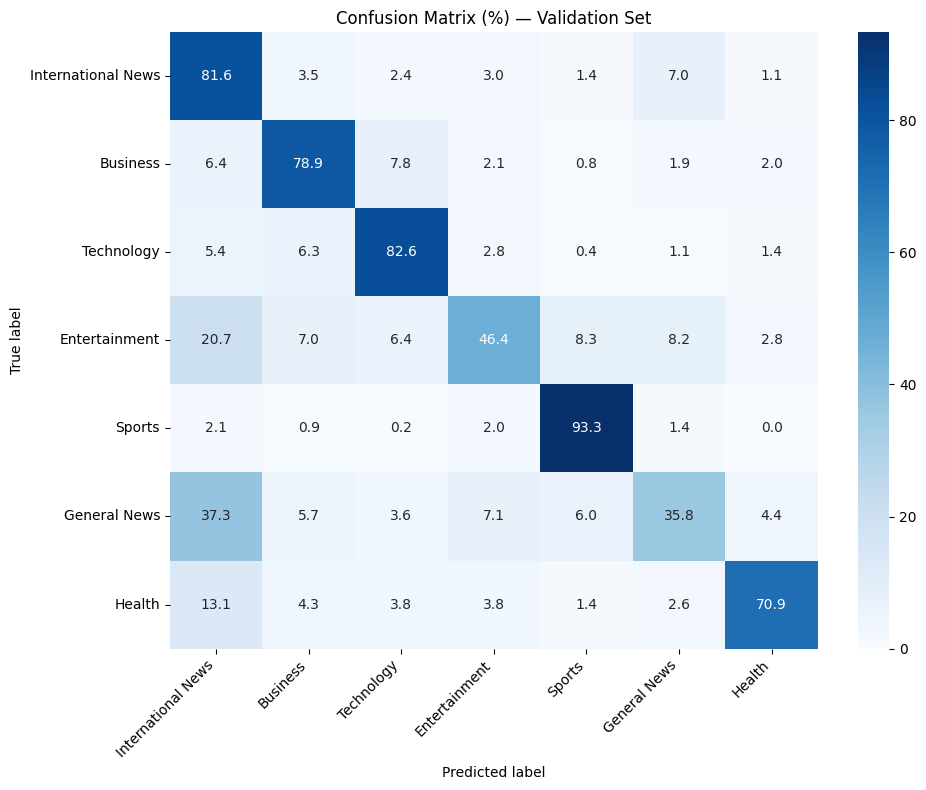

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = [category_map[i] for i in range(len(category_map))]

# --- PREDICT usando val_loader (evita OOM) ---
def predict_from_loader(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            data = batch['x'].to(device)
            target = batch['y']

            logits = model(data)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            
            all_preds.append(preds)
            all_targets.append(target.numpy())

    return np.concatenate(all_preds), np.concatenate(all_targets)

y_pred, y_true = predict_from_loader(model2, val_loader, device)

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix (%) — Validation Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()